# Validación SG 2D con placas impresas (las 3 placas)

Replica el pipeline de la validación 2D sintética del capítulo 5, con los defectos físicos impresos en las placas de calibración (grid 5×4, placas de 100, 150 y 200 mm).

1. **Defectos sintéticos**: los 20 defectos del CAD (mm) usado para imprimir (`parametros_<L>mm.csv`).
2. **Escaneos reales**: el mismo pipeline sobre los mapas de altura escaneados con el sensor.

Las 3 placas se procesan en paralelo y se comparan en figuras y tablas conjuntas.

**Correcciones sobre `sg_2D.ipynb`**:
- Se resta la base de la placa (5 mm) antes del SG: el estimador asume fondo cero (A = -f0).
- sigma se estima con la fórmula de la tesis: $\sigma = \sqrt{A/|\kappa|}$, con $\kappa$ autovalores del Hessiano $H = [[2a, c],[c, 2b]]$. El notebook original usaba autovalores de $Q = H/2$, lo que sesgaba sigma en $\sqrt{2}$.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

## 1. Configuración

- `PLACAS`: tamaños de placa a procesar (mm).
- `STEP`: paso del mapa sintético (mm/píxel), ajustado a la resolución del sensor. Para el escaneo real el paso se estima automáticamente desde el tamaño del mapa; si las 3 placas se escanean con el mismo paso, se usa el mismo `STEP` en el sintético para que la comparación sea consistente.
- `WINDOW_SIZE`: ventana SG 2D fija (óptima 31-61 según capítulo; 41 razonable).


In [30]:
PLACAS = [100, 150, 200]   # mm, placas a procesar
STEP = 0.04               # mm/píxel del mapa sintético (ajustar al paso real del sensor)
WINDOW_SIZE = 41          # ventana SG 2D fija
SEED = 42

BASE_DIR    = Path('/home/mario-ross/Proyectos/Tesis/python_pruebas')
RUTA_PARAMS = lambda L: BASE_DIR / f'stl/parametros_{L}mm.csv'
RUTA_ESCANEO = lambda L: BASE_DIR / f'escaneos/escaneo_{L}mm.npy'
RUTA_CENTROS = lambda L: BASE_DIR / f'escaneos/centros_{L}mm.csv'


## 2. Ground truth de las 3 placas

Se cargan los CSV generados junto a los STL: posición (mm), A, sigma1, sigma2 (mm) y theta (grados).


In [31]:
gts = {}
for L in PLACAS:
    gts[L] = pd.read_csv(RUTA_PARAMS(L))
    print(f'Placa {L} mm: {len(gts[L])} defectos')
gts[150].head()

Placa 100 mm: 20 defectos
Placa 150 mm: 20 defectos
Placa 200 mm: 20 defectos


,idx,col,row,xc_mm,yc_mm,A_mm,sigma1_mm,sigma2_mm,theta_deg
0,0,0,0,25.0,120.0,2.00,2.250,1.125,0.0
1,1,1,0,50.0,120.0,1.75,3.375,1.500,10.0
2,2,2,0,75.0,120.0,2.50,3.750,1.875,45.0
3,3,3,0,100.0,120.0,1.25,3.000,1.500,15.0
4,4,4,0,125.0,120.0,2.75,4.500,2.250,60.0


## 3. Funciones del pipeline SG 2D

Mismas que en `sg_2D.ipynb`, con dos correcciones: sigma a partir de los autovalores del Hessiano y conversión píxel → mm mediante el paso `step`.


In [32]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1, "La ventana debe ser impar"
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx*y_idx, x_idx, y_idx,
        np.ones_like(x_idx)
    ], axis=-1)
    A = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A.T @ A) @ A.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack([cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT)
                     for k in kernels], axis=-1)


def estimate_bump_parameters(centers, coeffs, step):
    """A (mm), sigma1, sigma2 (mm) y theta. Sigma = sqrt(A/|kappa|),
    con kappa = autovalores del Hessiano H = [[2a, c],[c, 2b]]."""
    results = []
    for (i0, j0) in centers:
        ii, jj = int(round(i0)), int(round(j0))
        a, b, c, d, e, f0 = coeffs[ii, jj]
        H = np.array([[2*a, c], [c, 2*b]])
        grad = np.array([d, e])
        dx, dy = -np.linalg.solve(H, grad)
        vi, vj = ii + dy, jj + dx
        xv, yv = vj - jj, vi - ii
        A_est = abs(-(a*xv**2 + b*yv**2 + c*xv*yv + d*xv + e*yv + f0))
        k1, k2 = np.linalg.eigvalsh(H)
        w1 = np.sqrt(A_est / max(abs(k1), 1e-12)) * step
        w2 = np.sqrt(A_est / max(abs(k2), 1e-12)) * step
        sigma1, sigma2 = max(w1, w2), min(w1, w2)
        # Eje mayor (sigma1) = autovector de la curvatura de MENOR magnitud
        idx = 0 if abs(k1) <= abs(k2) else 1
        principal_vec = np.linalg.eigh(H)[1][:, idx]
        theta = np.arctan2(principal_vec[1], principal_vec[0])
        results.append({'center': (vi, vj), 'A': A_est,
                        'sigma1': sigma1, 'sigma2': sigma2, 'theta': theta})
    return results


def add_rotated_gaussian(Z, x, y, xc, yc, sx, sy, A, th_deg):
    th = np.deg2rad(th_deg)
    X0, Y0 = x - xc, y - yc
    Xr =  np.cos(th) * X0 + np.sin(th) * Y0
    Yr = -np.sin(th) * X0 + np.cos(th) * Y0
    return Z + A * np.exp(-(Xr**2 / (2*sx**2) + Yr**2 / (2*sy**2)))


def build_synthetic(L, gt, step, seed=42, noise_std=0.01):
    """Mapa de altura sintético de la placa (base 5 mm - gaussianas)."""
    N = int(round(L / step)) + 1
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, 5.0)
    for _, r in gt.iterrows():
        Z = add_rotated_gaussian(Z, X, Y, r.xc_mm, r.yc_mm,
                                 r.sigma1_mm, r.sigma2_mm, -r.A_mm, r.theta_deg)
    if noise_std is not None:
        rng = np.random.default_rng(seed)
        Z += rng.normal(0, noise_std, Z.shape)
    return Z


def mm_to_px(gt, L, N):
    """Centros (fila, columna) en píxel. Las filas aumentan con y."""
    px_per_mm = (N - 1) / L
    return [(round(r.yc_mm * px_per_mm), round(r.xc_mm * px_per_mm))
            for _, r in gt.iterrows()]


def build_df(gt, est):
    rows = []
    for i, ((_, r), e) in enumerate(zip(gt.iterrows(), est)):
        rows.append({'idx': r.idx,
                     'A_real': r.A_mm, 'A_est': e['A'],
                     's1_real': r.sigma1_mm, 's1_est': e['sigma1'],
                     's2_real': r.sigma2_mm, 's2_est': e['sigma2'],
                     'sin2t_real': np.sin(2*np.deg2rad(r.theta_deg)),
                     'sin2t_est': np.sin(2*e['theta'])})
    return pd.DataFrame(rows)


def resumen_metricas(dic_dfs, label):
    """dic_dfs: {L: df} → tabla resumen con rho y MAE por placa."""
    rows = []
    for L, df in dic_dfs.items():
        fila = {'Placa (mm)': L}
        for col, lab in [('A', 'rho_A'), ('s1', 'rho_s1'), ('s2', 'rho_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            fila[lab] = np.corrcoef(real, estv)[0, 1]
        for col, lab in [('A', 'MAE_A'), ('s1', 'MAE_s1'), ('s2', 'MAE_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            fila[lab] = np.mean(np.abs(real - estv))
        rows.append(fila)
    out = pd.DataFrame(rows).set_index('Placa (mm)')
    print(f'--- {label} ---')
    display(out)
    return out


def corr_plots_multi(dic_dfs, label):
    """Una figura por parámetro; cada placa con su color."""
    params = [('A_real', 'A_est', 'Amplitud A (mm)'),
              ('s1_real', 's1_est', 'sigma1 (mm)'),
              ('s2_real', 's2_est', 'sigma2 (mm)'),
              ('sin2t_real', 'sin2t_est', 'sin(2·theta)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    for ax, (xcol, ycol, lab) in zip(axes, params):
        for L, df in dic_dfs.items():
            ax.scatter(df[xcol], df[ycol], s=45, alpha=0.7,
                       color=colores[L], label=f'{L} mm')
            for _, row in df.iterrows():
                ax.text(row[xcol], row[ycol], str(int(row['idx'])),
                        fontsize=8, color=colores[L],
                        va='bottom', ha='right')
        m, b = np.polyfit(pd.concat(dic_dfs.values())[xcol],
                          pd.concat(dic_dfs.values())[ycol], 1)
        xr = np.linspace(pd.concat(dic_dfs.values())[xcol].min(),
                         pd.concat(dic_dfs.values())[xcol].max(), 100)
        ax.plot(xr, m*xr + b, 'k--', alpha=0.5, label=f'y={m:.2f}x+{b:.2f}')
        ax.set_xlabel(f'{lab} real')
        ax.set_ylabel(f'{lab} estimado')
        ax.grid(True)
        ax.legend(fontsize='small')
    plt.suptitle(f'Correlación real vs estimado — {label} (3 placas)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 4. Validación sintética (las 3 placas)

Genera el mapa sintético de cada placa y ejecuta el pipeline completo.

**Nota**: se resta la base (5 mm) antes del SG, porque el estimador asume fondo cero.


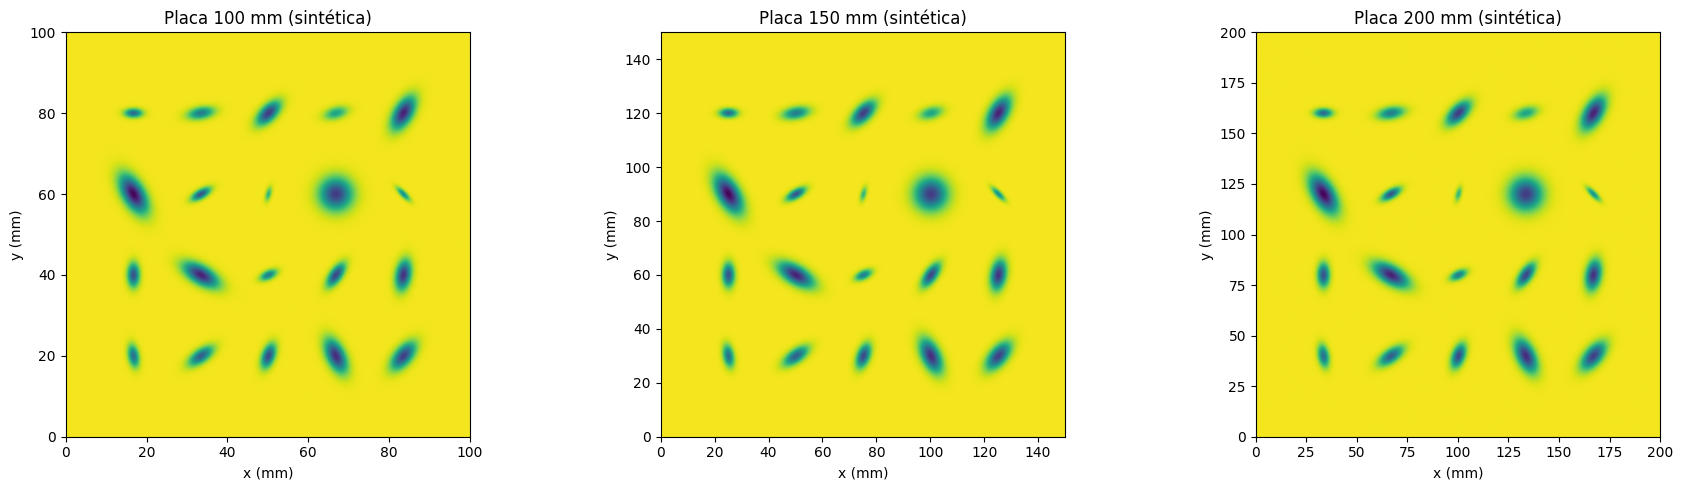

In [33]:
synth = {}
for L in PLACAS:
    Zs = build_synthetic(L, gts[L], STEP)
    N = Zs.shape[0]
    Zc = Zs - 5.0
    centers_px = mm_to_px(gts[L], L, N)
    coeffs = sg2d_jacobian_projection_cv2(Zc, WINDOW_SIZE)
    est = estimate_bump_parameters(centers_px, coeffs, STEP)
    synth[L] = {'Z': Zs, 'df': build_df(gts[L], est)}

fig, axes = plt.subplots(1, len(PLACAS), figsize=(6*len(PLACAS), 5))
for ax, L in zip(np.atleast_1d(axes), PLACAS):
    ax.imshow(synth[L]['Z'], cmap='viridis', origin='lower', extent=[0, L, 0, L])
    ax.set_title(f'Placa {L} mm (sintética)')
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.tight_layout()
plt.show()

In [34]:
resumen_synth = resumen_metricas({L: synth[L]['df'] for L in PLACAS}, 'SINTÉTICO')

--- SINTÉTICO ---


,rho_A,rho_s1,rho_s2,MAE_A,MAE_s1,MAE_s2
Placa (mm),,,,,,
100,0.998860,0.994463,0.999096,0.025499,0.150705,0.095251
150,0.999903,0.998485,0.999761,0.006264,0.102762,0.065691
200,0.999987,0.999063,0.999897,0.002297,0.078695,0.053037


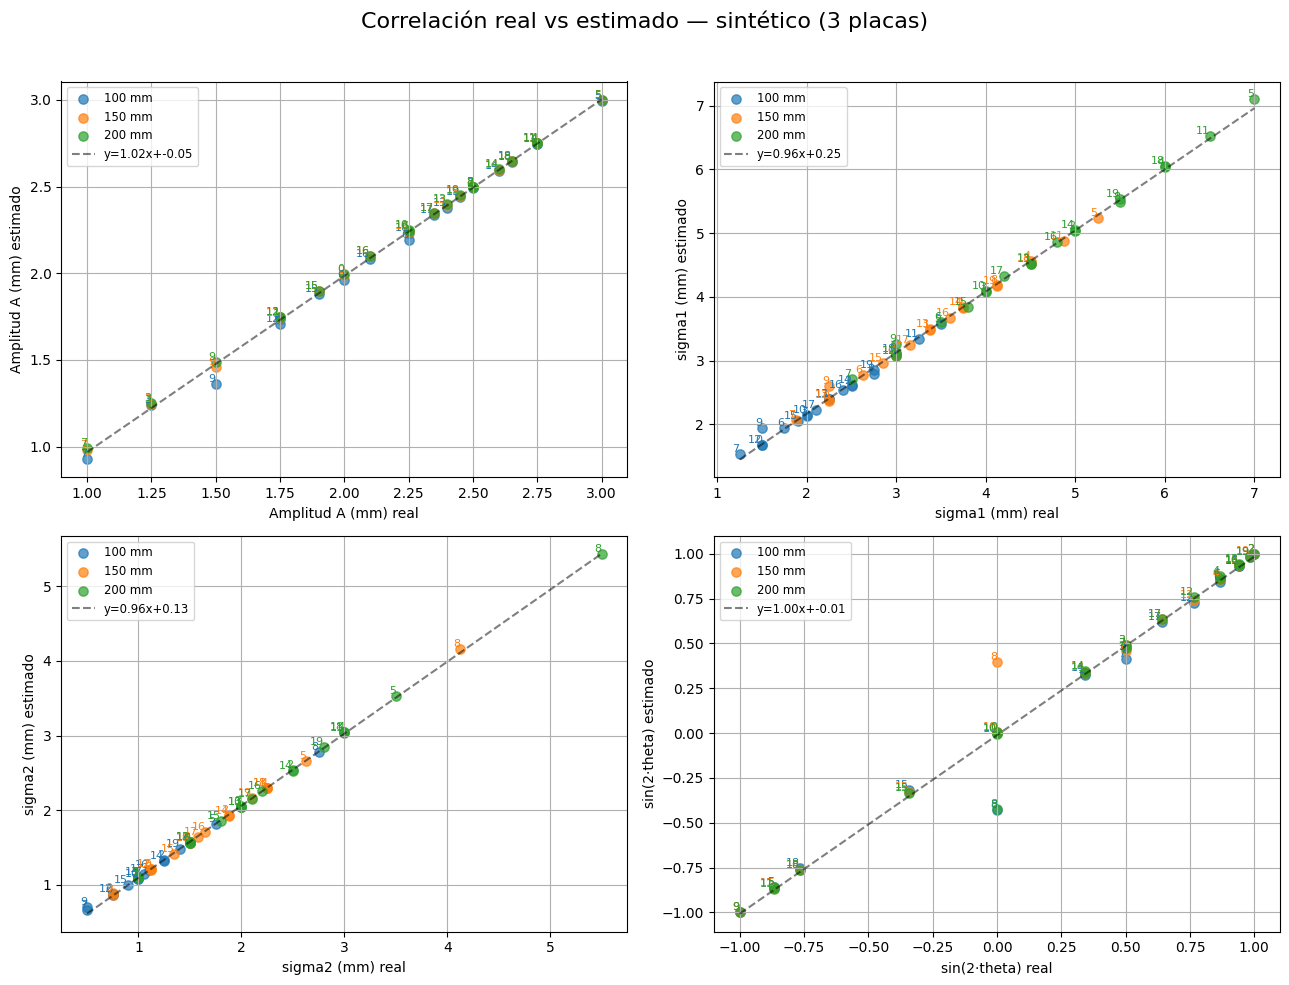

In [35]:
corr_plots_multi({L: synth[L]['df'] for L in PLACAS}, 'sintético')

## 5. Validación con escaneos reales (las 3 placas)

Para cada placa `escaneos/escaneo_<L>mm.npy` y `escaneos/centros_<L>mm.csv` (columnas `idx, x_px, y_px`). El paso real se estima desde el tamaño del mapa; si todas las placas se escanearon con el mismo paso, el sintético ya es comparable.

En el escaneo real se sustrae la **mediana** del mapa como base (robusta a la presencia de defectos).


In [36]:
def cargar_escaneo(path):
    ext = path.suffix.lower()
    if ext == '.npy':
        return np.load(path)
    if ext == '.csv':
        return pd.read_csv(path).values.astype(float)
    if ext == '.npz':
        with np.load(path) as z:
            return z[z.files[0]]
    if ext in ('.tif', '.tiff'):
        from PIL import Image
        return np.array(Image.open(path), dtype=float)
    raise ValueError(f'Extensión no soportada: {ext}')

reales = {}
for L in PLACAS:
    ps, pc = RUTA_ESCANEO(L), RUTA_CENTROS(L)
    if ps.exists() and pc.exists():
        Z_real = cargar_escaneo(ps)
        ctr = pd.read_csv(pc)
        step_real = L / (Z_real.shape[0] - 1)
        Zc = Z_real - np.median(Z_real)
        centers_real = [(int(r.y_px), int(r.x_px)) for _, r in ctr.iterrows()]
        coeffs = sg2d_jacobian_projection_cv2(Zc, WINDOW_SIZE)
        est = estimate_bump_parameters(centers_real, coeffs, step_real)
        reales[L] = {'Z': Z_real, 'step': step_real, 'df': build_df(gts[L], est)}
        print(f'Placa {L}: escaneo {Z_real.shape}, paso {step_real:.4f} mm/px, {len(ctr)} centros')
    else:
        print(f'Placa {L}: AVISO, faltan archivos de escaneo')

if reales:
    fig, axes = plt.subplots(1, len(reales), figsize=(6*len(reales), 5))
    for ax, L in zip(np.atleast_1d(axes), reales):
        ax.imshow(reales[L]['Z'], cmap='viridis', origin='lower')
        ax.set_title(f'Escaneo real placa {L} mm')
        ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    plt.tight_layout()
    plt.show()

Placa 100: AVISO, faltan archivos de escaneo
Placa 150: AVISO, faltan archivos de escaneo
Placa 200: AVISO, faltan archivos de escaneo


In [37]:
if reales:
    resumen_real = resumen_metricas({L: reales[L]['df'] for L in reales}, 'REAL')

In [38]:
if reales:
    corr_plots_multi({L: reales[L]['df'] for L in reales}, 'escaneo real')

## 6. Comparativa sintético vs real

Sobre la misma geometría, se compara directamente la estimación del simulador y del sensor físico por placa.


In [39]:
if reales:
    params = [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    for col, lab in params:
        plt.figure(figsize=(7, 6))
        for L in PLACAS:
            if L not in reales or L not in synth:
                continue
            xv = synth[L]['df'][f'{col}_est']
            yv = reales[L]['df'][f'{col}_est']
            plt.scatter(xv, yv, s=50, color=colores[L], label=f'{L} mm')
        lims = [min(pd.concat([synth[L]['df'][f'{col}_est'] for L in PLACAS]).min(),
                    pd.concat([reales[L]['df'][f'{col}_est'] for L in reales]).min()),
                max(pd.concat([synth[L]['df'][f'{col}_est'] for L in PLACAS]).max(),
                    pd.concat([reales[L]['df'][f'{col}_est'] for L in reales]).max())]
        plt.plot(lims, lims, 'k--', alpha=0.6)
        plt.xlabel(f'{lab} estimado (sintético)')
        plt.ylabel(f'{lab} estimado (real)')
        plt.title(f'{lab}: simulador vs sensor')
        plt.grid(True)
        plt.legend()
        plt.show()

## 7. Tabla comparativa final (todas las placas)

In [40]:
if reales:
    filas = []
    for L in PLACAS:
        if L not in reales:
            continue
        for col, lab in [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]:
            s, r = synth[L]['df'], reales[L]['df']
            filas.append({'Placa': f'{L} mm', 'Parámetro': lab,
                          'rho_sintético': np.corrcoef(s[f'{col}_real'], s[f'{col}_est'])[0, 1],
                          'rho_real': np.corrcoef(r[f'{col}_real'], r[f'{col}_est'])[0, 1],
                          'MAE_sintético (mm)': np.mean(abs(s[f'{col}_real']-s[f'{col}_est'])),
                          'MAE_real (mm)': np.mean(abs(r[f'{col}_real']-r[f'{col}_est']))})
    display(pd.DataFrame(filas))